In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/data.csv")  # adjust filename if needed

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


df.shape
df.info()
df.describe(include="all").T

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]





    Series([], dtype: int64)





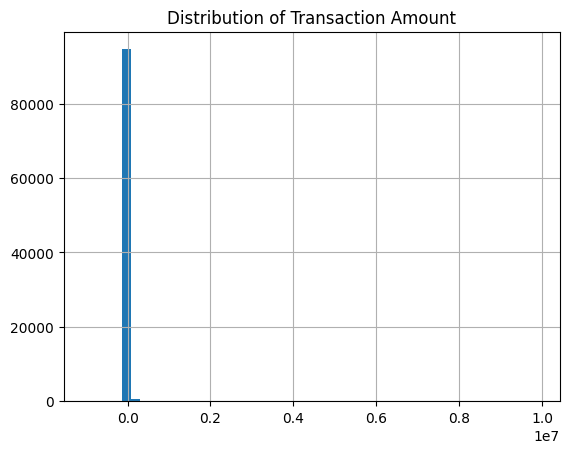

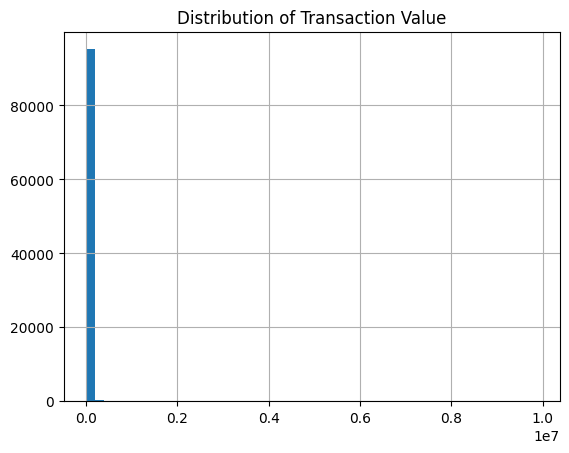

In [3]:
import matplotlib.pyplot as plt

df["Amount"].hist(bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()

df["Value"].hist(bins=50)
plt.title("Distribution of Transaction Value")
plt.show()

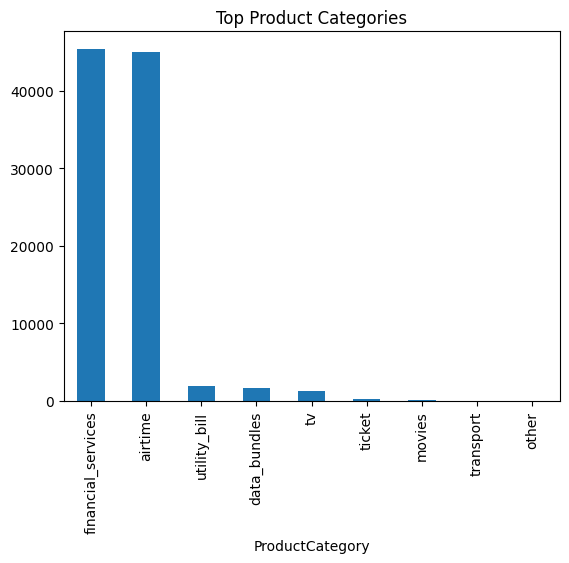

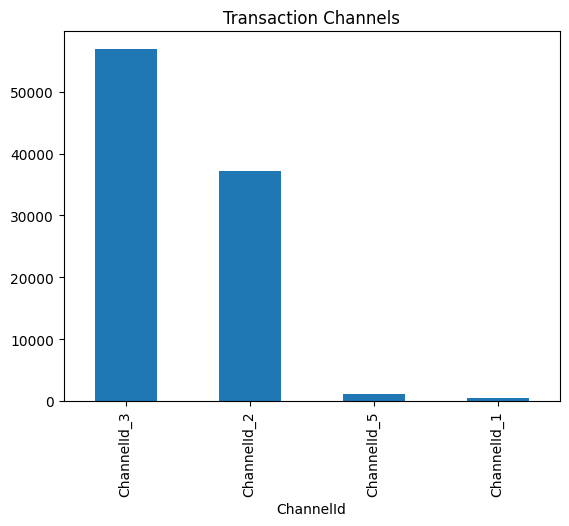

In [4]:
df["ProductCategory"].value_counts().head(10).plot(kind="bar")
plt.title("Top Product Categories")
plt.show()

df["ChannelId"].value_counts().plot(kind="bar")
plt.title("Transaction Channels")
plt.show()

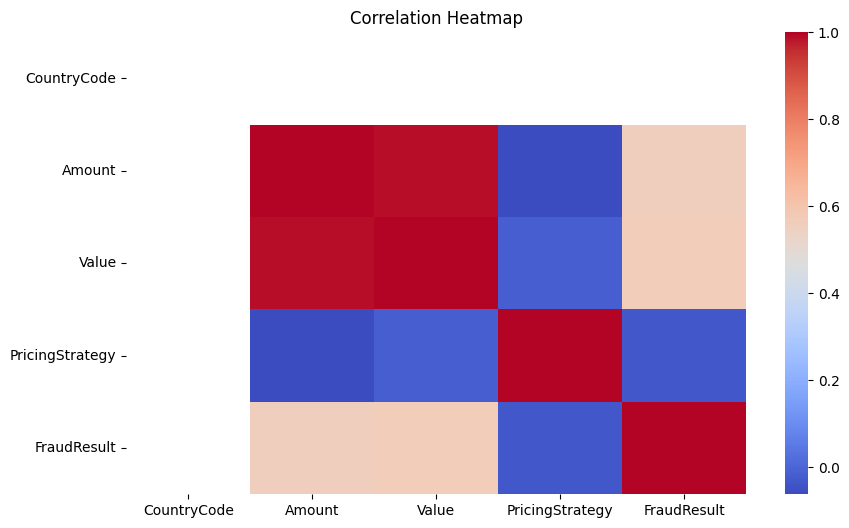

In [5]:
num_df = df.select_dtypes(include=np.number)

corr = num_df.corr()

import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

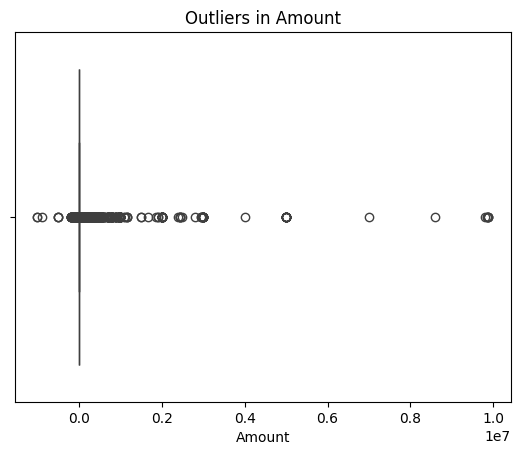

In [6]:
import seaborn as sns

sns.boxplot(x=df["Amount"])
plt.title("Outliers in Amount")
plt.show()

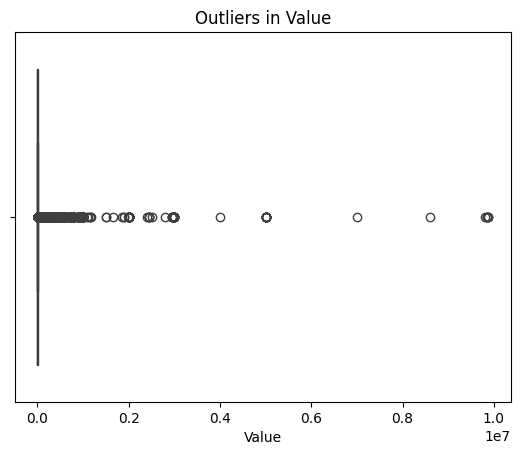

In [7]:
sns.boxplot(x=df["Value"])
plt.title("Outliers in Value")
plt.show()

## Key Insights from EDA

1. **Severe Class Imbalance**: The target variable `FraudResult` is extremely imbalanced (~0.2% fraud cases). This will require careful handling (e.g., class weighting, oversampling, or anomaly detection techniques) during modeling.

2. **Heavy Skew and Outliers in Monetary Features**: Both `Amount` and `Value` are highly right-skewed with many extreme outliers. These will need robust scaling or transformation (e.g., log transform, Winsorization) in feature engineering.

3. **Dominant Transaction Types**: `financial_services` and `airtime` dominate the dataset. Fraud patterns are likely to differ significantly across `ProductCategory`, making this a strong candidate for feature engineering.

4. **High Correlation between Amount and Value**: These two features are very strongly correlated, suggesting potential multicollinearity that should be addressed (e.g., keep one or create a new derived feature).

5. **Limited Time Window**: All transactions occurred in November–December 2018. Time-based features (hour of day, day of week, etc.) could reveal behavioral fraud patterns.

**Next Steps**: Focus on outlier treatment, time feature extraction, categorical encoding (especially `ProductCategory`, `ProviderId`), and prepare for imbalanced classification in the modeling phase.